# TP 4 - Grupo 7

André Filipe Dourado Pinheiro - A108473

Tiago Silva Costa - A108657

# Problema 1 - Sistemas híbridos

Pretende-se modelar o controle de tráfego marítimo num canal estreito entre dois portos, identificados como $A$ e $B$ e situados situados em cada um dos extremos do canal. O tráfego esta restrito a dois navios: um viajando na rota  $\,A{\to}B\,$ e outro viajando na rota $\,B{\gets}A\,$. 
O sistema híbrido é formado por quatro autómatos híbridos: os dois navios e um semáforo que controla o acesso de cada um dos navios aos diferentes sectores. 
A sua descrição é baseada no seguinte mapa

![](./map.png)

- A geometria navegável do canal está organizada em 15 sectores  enumerados $\,\mathbf{s}_0,...,\mathbf{s}_{14}\,$. Os sectores são todos quadrados com lado $\,1\, \mathsf{km}$ ; para identificar a posição de um navio dentro o sector $\,\mathsf{s}_i\,$ usa-se um referencial próprio $\,(x,y)\,$ com origem no canto inferior esquerdo.
- A condição de segurança suficiente pretende garantir que em qualquer dos sectores  não podem estar simultaneamente os dois navios. A condição dita de segurança forte exige que, para além de de se verificar a condição de “segurança suficiente”  se verifique também que nenhum dos navios é forçado a se imobilizar aguardando que o outro abandone o sector para onde pretende transitar.
- Os modos do semáforo são pares $\,(s_A,s_B)\,$ em que $\,s_A\,$ é o setor onde se encontra o navio saído do porto $A$ e $\,s_B\,$ é o setor onde se encontra o navio $\,B\,$. Os sinais do semáforo (vermelho, amarelo, verde) são os sincronismos (ou ausência deles) que esse semáforo faz com as transições de modo em cada um dos navios: “verde” corresponde a permissão de o navio transitar de sector, “amarelo” corresponde à autorização de transição do navio para o sector vizinho do sector onde está o outro navio, “vermelho” é não-sincronismo.
- A única variável contínua no semáforo é o tempo mestre  $\,t\,$ que é incrementado com o sincronismo com as alterações de modo nos navios
- Os modos do navio  são definidos pelos sectores $\,s\,$. A cada modo estão associados  parâmetros racionais, constantes dentro de cada sector mas variando de sector para sector.
    - $\gamma > 0\,$ é a aceleração linear  definida pela propulsão do navio
    - $\varepsilon\;$   é a  força exercida pela corrente no canal que actua a favor ou contra a trajectória.
    - $\phi\,$ é o rumo do navio definido como o ângulo que a trajetória do movimento linear faz com o eixo horizontal.
    - $V\,$ é o limite superior na velocidade do navio. 

> Na rota $\,A\to B\,$ os sectores $\{s_{11},s_{13}\}\,$ e $\{s_2,s_4\}\,$ são zonas de aceleração  ($\,\gamma \simeq 1\,$); os sectores $\,\{s_1,s_3\}\,$ e $\,\{s_{12},s_{14}\}\,$ são zonas de desaceleração ($\,\gamma\simeq 0\,$); os sectores $\{s_5,s_7,s_9\}\,$ e $\{s_6,s_8,s_{10}\}\,$ são zonas de velocidade aproximadamente constante e de cruzeiro; finalmente $\,\{s_0\}\,$ é a zona de velocidade  baixa aproximadamente constante. <br>Na rota $\,B\to A\,$ as zonas de aceleração e desaceleração aparecem trocadas. 

- Dentro de cada modo o movimento linear do navio é  representado diretamente pelas variáveis contínuas tempo $\,\tau\geq 0\,$ , velocidade $\,\upsilon\geq 0\,$ e deslocamento $\,z\geq 0\,$. O movimento é regido pelas equações diferenciais $$\left\{\begin{array}{lclcl} \dot{\upsilon} + \sigma\,\upsilon &=& \gamma &\text{se}& \upsilon\leq V \\ \dot{\upsilon} + \sigma\,\upsilon &=& \varepsilon  &\text{se}&\upsilon > V \\ \dot{z} &=& \upsilon \end{array}\right.$$ sendo $\sigma\,$ , o coeficiente de atrito com a àgua, uma constante positiva que é independente do modo mas depende do navio. As condições iniciais deste sistema de equações diferenciais são  $z(0) = 0$ e $\upsilon(0)= \upsilon_0\,$ , sendo a constante $\,\upsilon_0\,$ a velocidade que transita do modo anterior.

> Assume-se que as diferenças de rumo em cada transição são suficientemente pequenas para não afectar significativamente o valor de $\,\upsilon_0\,$. 

- A posição  do navio  é definida pelo par de coordenadas $$x = x_0 + z\,\cos(\phi)\qquad$$ e $$ y \equiv y_0 + z\,\sin(\phi)$$ sendo $(x_0,y_0)\,$ o ponto do sector onde a trajetória se inicia. O facto de a trajetória estar contida num quadrado de lado $\,1\,$ impõe as restrições $$(0 \leq x_0 + z\,\cos(\phi) \leq 1)\,\land\,(0\leq y_0 + z\,\sin(\phi)\leq 1)$$

Pretende-se:

1. Criar os três autómatos híbridos representando ambos os navios e o semáforo. Definir 
    1. os modos/locais
    2. as variáveis de modo e as equações de fluxo para cada modo
    3. os “jumps” e “eventos” e os “switch” de cada “jump”; identificar os sincronismos entre os vários autómatos.
2. Construir o FOTS que representa o sistema híbrido global: identificar o predicado que descreve a condição de segurança.
3. Verificar, usando BMC ou $k$-indução, a segurança do sistema quer na versão suficiente como na versão forte.


## Modelação

Para a resolução do problema em questão, decidiu-se usar o módulo `pysmt.shortcuts`, com as funcionalidades possíveis para a utilização de um SMT *Solver*. Importam-se também os tipos deste *Solver*, a partir do módulo `pysmt.typing`.



In [1]:
from z3 import *
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
from pysmt.shortcuts import *
from pysmt.typing import REAL, INT, BOOL
from fractions import Fraction

## Sistema Híbrido

Para responder à questão 1, definimos o sistema híbrido composto pela composição paralela dos autómatos dos dois navios e do autómato do semáforo.

***

### Autómatos dos Navios

Os navios têm comportamentos simétricos na física, diferenciando-se pelas condições iniciais, rotas e  parâmetros dos setores.

**Modos:** Os modos correspondem aos setores geométricos do canal. $$Q = \{ \mathbf{s}_0, \mathbf{s}_1, \dots, \mathbf{s}_{14} \}$$

**Variáveis de Estado:** O estado contínuo de cada navio é definido por:
$$\mathsf{X} \equiv (s, z, x_0, y_0, v, t)$$

Onde:
 - $s \in Q$: O setor atual (variável discreta).
 - $z \in \mathbb{R}_{\ge 0}$: Deslocamento linear dentro do setor.
 - $x_0, y_0 \in \mathbb{R}$: Coordenadas globais de entrada no setor atual.
 - $v \in \mathbb{R}_{\ge 0}$: Velocidade linear.
 - $t \in \mathbb{R}_{\ge 0}$: Tempo mestre.

**Predicado $\mathbf{init}(\mathsf{X})$:**

Para o **Navio A**:
$$\mathbf{init}_A(\mathsf{X}) \equiv (s = \mathbf{s}_{11}) \land (z = 0) \land (x_0 = 0) \land (y_0 = 0.2) \land (v = 0.4) \land (t = 0)$$

Para o **Navio B**:
$$\mathbf{init}_B(\mathsf{X}) \equiv (s = \mathbf{s}_{12}) \land (z = 0) \land (x_0 = 1.0) \land (y_0 = 0.8) \land (v = 0.4) \land (t = 0)$$

*Nota: Para fins de exemplo, definimos as coordenadas iniciais dentro do setor, embora estas possam ser genéricas. Por esse mesmo motivos, escolhemos os setores $s_{11}$ e $s_{12}$*

**Equações de fluxo:**
Dentro de cada modo $\mathbf{s}_i$, o comportamento contínuo é governado pelas EDOs dadas pelo enunciado, dependendo dos parâmetros $\gamma, \varepsilon, V$ do setor.

$$\mathbf{flow}(\mathsf{X}, \dot{\mathsf{X}}) \equiv \begin{cases} 
\dot{t} = \Delta t \\
\dot{z} = v \\
\dot{v} = \gamma - \sigma v & \text{se } v \le V \\
\dot{v} = \varepsilon - \sigma v & \text{se } v > V
\end{cases}$$

**Transições:** As transições discretas ocorrem quando o navio atinge a fronteira do setor e tenta entrar num setor adjacente. Definimos dois tipos de transição: **Move** (Mover-se) e **Wait** (Esperar/Bloqueio).

Seja $\mathsf{next}(s)$ o setor seguinte na rota do navio e $\mathsf{sig}$ o sinal recebido do semáforo.

Além disso, seja $$ \mathsf{bounded} \equiv (0 \leq x_0 + z\,\cos(\phi) \leq 1)\,\land\,(0\leq y_0 + z\,\sin(\phi)\leq 1)$$

Podemos assim definir os dois tipos de transição.

1.  **_Move_:**
    Ocorre quando o navio atinge o fim do setor e o semáforo permite (Verde ou Amarelo).
     - **Guarda:** $\neg \mathsf{bounded} \land (\mathsf{sig} \in \{\text{Verde}, \text{Amarelo}\})$
     - **Eventos:**
         - $s' = \mathsf{next}(s)$
         - $z' = 0$
         - $(x_0', y_0')$ atualizados para o ponto de entrada no novo setor.
         - $v' = v$ (continuidade da velocidade).

2.  **_Wait_:**
    Ocorre quando o navio tenta entrar num setor ocupado (Sinal Vermelho).
     - **Guarda:** $\neg \mathsf{bounded} \land (\mathsf{sig} = \text{Vermelho})$
     - **Eventos:**
         - $s' = s$ (permanece no mesmo setor)
         - $z' = z$ (posição fixa na fronteira)
         - $v' = 0$ (imobilização forçada)

***

### Autómato do Semáforo

O semáforo observa o estado dos dois navios e emite sinais de sincronismo.

**Modos:** O estado discreto do semáforo é o par de setores onde os navios estão.
$$Q = \{ (s_A, s_B) \mid s_A, s_B \in \{ \mathbf{s}_0, \dots, \mathbf{s}_{14} \} \}$$

**Lógica de Sinais:** O semáforo não possui variáveis contínuas próprias além do tempo mestre, mas define as condições de guarda para os navios. 

Suponhamos um cenário em que temos os navios $A$ e $B$ localizados nos setores $s_A$ e $s_B$ e que o navio $A$ deseja entrar no setor $s'$. Portanto, temos os seguintes cenários.

 - **Vermelho:** Se $s' = s_B$, pois o setor destino está ocupado.
 - **Amarelo:** Se $s' \in \text{Vizinhos}(s_{B})$, pois o setor destino é adjacente ao setor do outro navio.
 - **Verde:** Caso contrário.

Em que $\text{Vizinhos}(s)$ é o conjunto de todos os setores que são adjacentes a $s$.

**Transições:**
O semáforo transita instantaneamente $(s_A, s_B) \to (s_A', s_B')$ sempre que o autómato de um dos navios executa uma transição de mudança de setor.

## Implementação

Começamos por definir a topologia do canal e as constantes físicas que governam as equações diferenciais. Para isso, defenimos alguns dicionários para isso:

 - `GLOBAL_MAP`: Mapeia o ID de cada setor ($s_0, \dots, s_{14}$) para a sua coordenada global $(x,y)$ do canto inferior esquerdo. Isto permite converter o deslocamento local $z$ numa posição global para efeitos de visualização e verificação de fronteiras.

 - `NEIGHBORS`: Define a matriz de adjacência do grafo de setores. 

 - `SECTOR_PHI`: O ângulo do rumo ($\phi$).

 - `TYPES` e `PARAMS`: Associam cada setor a um perfil de movimento, definindo os valores de $\gamma$ (propulsão), $\varepsilon$ (corrente) e $V$ (limite).

 - `SIGMA`, `DT`: Constantes globais para o atrito ($\sigma$) e o passo de tempo da simulação ($\Delta t = 0.25s$).



In [2]:

GLOBAL_MAP = {
    11: (0.0, 1.5), 13: (0.0, 0.5),
    5:  (1.0, 2.0), 7:  (1.0, 1.0), 9: (1.0, 0.0),
    1:  (2.0, 1.5), 3:  (2.0, 0.5),
    0:  (3.0, 1.0),
    2:  (4.0, 1.5), 4:  (4.0, 0.5),
    6:  (5.0, 2.0), 8:  (5.0, 1.0), 10: (5.0, 0.0),
    12: (6.0, 1.5), 14: (6.0, 0.5)
}

NEIGHBORS = {
    11: [5, 13], 13: [11, 9],
    5: [11, 1, 7], 7: [5, 1, 3, 9], 9: [13, 7, 3],
    1: [5, 7, 0], 3: [7, 9, 0],
    0: [1, 3, 2, 4], 
    2: [0, 6, 8], 4: [0, 8, 10],
    6: [2, 12, 8], 8: [2, 4, 6, 10, 12, 14], 10: [4, 8, 14],
    12: [6, 8], 14: [8, 10]
}

SECTOR_PHI = {
    11: 0.30,  
    5: -0.25,  
    1: -0.35,   
    0: 0.10,   
    2: 0.35,  
    6: 0.25,  
    12: 0.0, 
    
    13: -0.40,  
    7: 0.0,     
    3: 0.40,   
    
    14: 0.0,    
    8: 0.0,     
    10: -0.25,  
    4: -0.35,  
    9: 0.40     
}

PARAMS = { 
    'ACCEL': (1.5, 0.4, 2.5), 'DECEL': (0.0, -0.3, 1.8), 
    'CRUISE': (0.8, 0.0, 1.6), 'SLOW': (0.3, 0.0, 0.6) 
}

TYPES = { 
    11:'ACCEL', 13:'ACCEL', 2:'ACCEL', 4:'ACCEL', 
    1:'DECEL', 3:'DECEL', 12:'DECEL', 14:'DECEL', 
    0:'SLOW' 
} 

SIGMA, DT = Real(0.5), Real(0.25)

Declaram-se as variáveis para cada um dos estados.

In [3]:
def declare(S, i):
    s = {}
    s['t'] = Symbol(f"{S}_t_{i}", REAL)
    for ship in ['A', 'B']:
        for var, tipo in [('s', INT), ('z', REAL), ('x0', REAL), ('y0', REAL), ('v', REAL), ('sig', INT)]:
            s[f'{ship}_{var}'] = Symbol(f"{S}_{ship}_{var}_{i}", tipo)
    return s

Define-se o estado inicial.

In [4]:
def init(s):
    return And(
        Equals(s['t'], Real(0.0)),
        
        # === NAVIO A - Começa no CANTO SUPERIOR ===
        Equals(s['A_s'], Int(11)), 
        Equals(s['A_z'], Real(0.0)),
        Equals(s['A_x0'], Real(0.2)),   # Mais à esquerda
        Equals(s['A_y0'], Real(0.7)),   # ALTO no setor (0.7 de 1.0)
        Equals(s['A_v'], Real(0.5)),    
        Equals(s['A_sig'], Int(0)),
        
        # === NAVIO B - Começa no CANTO INFERIOR ===
        Equals(s['B_s'], Int(12)), 
        Equals(s['B_z'], Real(0.0)),
        Equals(s['B_x0'], Real(0.8)),   # Mais à direita
        Equals(s['B_y0'], Real(0.3)),   # BAIXO no setor (0.3 de 1.0)
        Equals(s['B_v'], Real(0.5)),    
        Equals(s['B_sig'], Int(0))
    )


Para implementar o motor físico que rege cada setor, devemos implementar a discretização das equações diferenciais.

Para implementar a física no estilo da discretização de Euler, onde se expressa a variação da variável ($v' - v$) como função de uma taxa multiplicada pelo intervalo de tempo ($t' - t$), devemos adaptar as Equações Diferenciais Ordinárias (EDOs) do enunciado para esse formato algébrico.

Como as EDOs são:
1.  Velocidade: $\dot{v} = (\gamma \text{ ou } \varepsilon) - \sigma v$
2.  Posição: $\dot{z} = v$

Vamos ter:

1. Para a Velocidade ($v$):
$$ v' - v = (\underbrace{\text{Força} - \sigma \cdot v}_{\text{Taxa}}) \times (t' - t) $$

*Onde "Força" é $\gamma$ (aceleração) ou $\varepsilon$ (corrente).*

2. Para o Deslocamento ($z$):
$$ z' - z = (\underbrace{v}_{\text{Taxa}}) \times (t' - t) $$

Por isso, criamos a função `get_physics` que é responsável por obter os parametros de cada setor e realizar a discretização.

In [5]:
def get_physics(s, p, ship_name):
    v, v_next = s[f'{ship_name}_v'], p[f'{ship_name}_v']
    z, z_next = s[f'{ship_name}_z'], p[f'{ship_name}_z']
    t, t_next = s['t'], p['t']
    sec = s[f'{ship_name}_s']
    
    dt_term = Minus(t_next, t)

    # Determinação dos parametros com base no setor
    gamma, eps, v_lim = Real(0.0), Real(0.0), Real(1.0)
    for sid in GLOBAL_MAP:
        stype = TYPES.get(sid, 'CRUISE')
        if ship_name == 'B': 
            if stype == 'ACCEL': stype = 'DECEL'
            elif stype == 'DECEL': stype = 'ACCEL'
        
        param = PARAMS[stype]
        cond = Equals(sec, Int(sid))
        
        gamma = Ite(cond, Real(param[0]), gamma)
        eps   = Ite(cond, Real(param[1]), eps)
        v_lim = Ite(cond, Real(param[2]), v_lim)

    # Taxa da Velocidade
    rate_accel = Minus(gamma, Times(SIGMA, v))
    rate_drag  = Minus(eps, Times(SIGMA, v))
    rate_v = Ite(LE(v, v_lim), rate_accel, rate_drag)

    # V' - V = rate_v * (T' - T)
    eq_velocity = Equals(Minus(v_next, v), Times(rate_v, dt_term))
    
    # Z' - Z = rate_z * (T' - T)
    eq_position = Equals(Minus(z_next, z), Times(v, dt_term))

    return And(eq_velocity, eq_position)

Com o motor físico definido, podemos defenir as transições do nosso sistema na função `trans`.

A estratégia utilizada envolve três fases principais, onde o semáforo atua como coordenador central.

#### Fase 1: Projeção Física
Cada navio projeta a sua posição futura baseada na física do movimento:

1. Calcula $z_{projected} = z + v\times \Delta v$.
2. Determina coordenadas globais `(pg_x, pg_y)`.
3. Verifica se ainda está dentro dos limites do setor atual (in_bounds)

#### Fase 2: Determinação de Intenções
O sistema identifica para qual setor cada navio pretende transitar:

1. Verifica validade geométrica (posição projetada dentro do setor destino).
1. Verifica validade topológica (setor destino é vizinho na rede).
1. Gera lista de intenções: `(dst_id, valid_entry, cand_x, cand_y)`.

#### Fase 3: Decisão do Semáforo

O semáforo coordena as transições com base em prioridades entre os navios.

**Navio A (prioridade alta)**
- Luz vermelha **apenas** se o Navio B **estiver fisicamente** no setor de destino  
- Ignora se o Navio B **apenas pretende** ir para o setor

**Navio B (prioridade baixa)**
- Luz vermelha se o Navio A **estiver no destino** **ou** **pretender ir para lá**
- Deve **aguardar a passagem** do Navio A

***

**Sinais do Semáforo**
 - Vermelho (2): Bloqueio obrigatório
 - Amarelo (1): Navegação em vizinhança
 - Verde (0): Passagem livre

***

**Tipos de Transição**:

__STAY (dentro dos limites)__
- Aplica física contínua
- Mantém setor atual
- Sinal verde

__MOVE (luz não-vermelha)__
- Transita para novo setor
- Reset $z = 0$, mantém velocidade
- Atualiza coordenadas de entrada

__BLOCK (luz vermelha)__
- Permanece no setor atual
- Velocidade reduz para 0
- Regista sinal vermelho

In [6]:
def trans(s, p):
    time_step = Equals(Minus(p['t'], s['t']), DT)
    
    # PROJEÇÃO FÍSICA DOS NAVIOS
    projections = {}
    for name in ['A', 'B']:
        cs = s[f'{name}_s']
        cz = s[f'{name}_z']
        cx0 = s[f'{name}_x0']
        cy0 = s[f'{name}_y0']
        cv = s[f'{name}_v']
        
        # Projeção física
        z_projected = Plus(cz, Times(cv, DT))
        
        loc_x, loc_y = Real(0.0), Real(0.0)
        glob_x_origin, glob_y_origin = Real(0.0), Real(0.0)
        
        for sid, (gx, gy) in GLOBAL_MAP.items():
            is_sec = Equals(cs, Int(sid))
            ang = SECTOR_PHI.get(sid, 0.0)
            if name == 'B': ang += math.pi
            
            lx = Plus(cx0, Times(z_projected, Real(math.cos(ang))))
            ly = Plus(cy0, Times(z_projected, Real(math.sin(ang))))
            
            loc_x = Ite(is_sec, lx, loc_x)
            loc_y = Ite(is_sec, ly, loc_y)
            glob_x_origin = Ite(is_sec, Real(gx), glob_x_origin)
            glob_y_origin = Ite(is_sec, Real(gy), glob_y_origin)
        
        pg_x = Plus(glob_x_origin, loc_x)
        pg_y = Plus(glob_y_origin, loc_y)
        
        in_bounds = And(GE(loc_x, Real(0.0)), LE(loc_x, Real(1.0)),
                        GE(loc_y, Real(0.0)), LE(loc_y, Real(1.0)))
        
        projections[name] = {
            'in_bounds': in_bounds,
            'pg_x': pg_x,
            'pg_y': pg_y,
            'loc_x': loc_x,
            'loc_y': loc_y
        }
    

    # SEMÁFORO DECIDE OS SINAIS
    def get_intended_sector(name, proj):
        """Determina para qual setor o navio quer ir"""
        cs = s[f'{name}_s']
        intended_sectors = []
        
        for dst_id, (dgx, dgy) in GLOBAL_MAP.items():
            cand_x = Minus(proj['pg_x'], Real(dgx))
            cand_y = Minus(proj['pg_y'], Real(dgy))
            
            valid_geo = And(
                GE(cand_x, Real(0)), LE(cand_x, Real(1)),
                GE(cand_y, Real(0)), LE(cand_y, Real(1)),
                Not(Equals(cs, Int(dst_id)))
            )
            
            # Topologia
            topo_conds = []
            for src_id, neighbors_list in NEIGHBORS.items():
                if dst_id in neighbors_list:
                    topo_conds.append(Equals(cs, Int(src_id)))
            is_valid_neighbor = Or(topo_conds) if topo_conds else FALSE()
            
            valid_entry = And(valid_geo, is_valid_neighbor)
            
            intended_sectors.append((dst_id, valid_entry, cand_x, cand_y))
        
        return intended_sectors
    
    # Determina intenções de ambos os navios
    intentions_A = get_intended_sector('A', projections['A'])
    intentions_B = get_intended_sector('B', projections['B'])
    

    # LÓGICA DO SEMÁFORO: O semáforo verifica se há conflitos e atribui sinais
    transitions = []
    
    for name in ['A', 'B']:
        other_name = 'B' if name == 'A' else 'A'
        
        cs = s[f'{name}_s']
        cz = s[f'{name}_z']
        cx0 = s[f'{name}_x0']
        cy0 = s[f'{name}_y0']
        cv = s[f'{name}_v']
        
        ns = p[f'{name}_s']
        nz = p[f'{name}_z']
        nx0 = p[f'{name}_x0']
        ny0 = p[f'{name}_y0']
        nv = p[f'{name}_v']
        nsig = p[f'{name}_sig']
        
        other_s = s[f'{other_name}_s']
        proj = projections[name]
        intentions = intentions_A if name == 'A' else intentions_B
        other_intentions = intentions_B if name == 'A' else intentions_A
        
        physics_flow = get_physics(s, p, name)
        
        # CASO 1: STAY - dentro dos limites
        stay = And(
            proj['in_bounds'],
            physics_flow,
            Equals(ns, cs),
            Equals(nx0, cx0),
            Equals(ny0, cy0),
            Equals(nsig, Int(0))
        )
        
        # CASO 2: Saiu dos limites - semáforo decide
        all_moves_and_blocks = []
        
        for dst_id, valid_entry, cand_x, cand_y in intentions:
            if not valid_entry:
                continue
            
            # SEMÁFORO: verifica conflitos
            # 1. Outro navio está no destino?
            other_occupies = Equals(other_s, Int(dst_id))
            
            # 2. Outro navio quer o mesmo destino?
            other_wants_same = FALSE()
            for other_dst, other_valid, _, _ in other_intentions:
                if other_dst == dst_id:
                    other_wants_same = Or(other_wants_same, other_valid)
            
            # 3. Conflito com vizinhança?
            yellow_conds = []
            for potential_other_loc, neighbors_of_loc in NEIGHBORS.items():
                if dst_id in neighbors_of_loc:
                    yellow_conds.append(Equals(other_s, Int(potential_other_loc)))
            is_yellow = And(
                Or(yellow_conds) if yellow_conds else FALSE(),
                Not(other_occupies),
                Not(other_wants_same)
            )
            
            # DECISÃO DO SEMÁFORO
            # Vermelho: ocupado OU ambos querem (implementação da prioridade)
            has_priority = TRUE() if name == 'A' else FALSE()
            
            is_red = Or(
                other_occupies,
                And(other_wants_same, Not(has_priority))
            )
            
            calc_sig = Ite(is_red, Int(2), Ite(is_yellow, Int(1), Int(0)))
            
            # MOVE - luz verde ou amarela
            move = And(
                valid_entry,
                Not(is_red),
                Equals(ns, Int(dst_id)),
                Equals(nz, Real(0.0)),
                Equals(nv, cv),
                Equals(nx0, cand_x),
                Equals(ny0, cand_y),
                Equals(nsig, calc_sig)
            )
            
            # BLOCK - luz vermelha
            block = And(
                valid_entry,
                is_red,
                Equals(ns, cs),
                Equals(nz, cz),
                Equals(nv, Real(0.5)),
                Equals(nx0, cx0),
                Equals(ny0, cy0),
                Equals(nsig, Int(2))
            )
            
            all_moves_and_blocks.append(Or(move, block))
        
        out_of_bounds = And(
            Not(proj['in_bounds']),
            Or(all_moves_and_blocks) if all_moves_and_blocks else FALSE()
        )
        
        transitions.append(Or(stay, out_of_bounds))
    
    return And(time_step, And(transitions))

### Ilustração

Vamos definir as funções `print_trace_log` e ` plot_static_image`, que serão responsáveis pelo *print* das variáveis e do mapa com o percurso dos navios, respetivamente. 

Além disso, criamos uma função auxiliar `extract_val` para extrair sem erros os valores do modelo.

In [7]:
def extract_val(model, node):
    val = model.get_py_value(node)
    if hasattr(val, 'numerator'): return float(val.numerator) / float(val.denominator)
    if isinstance(val, int): return float(val)
    if isinstance(val, bool): return val
    if hasattr(val, 'is_true'): return val.is_true()
    try: return float(val)
    except: return 0.0

def print_trace_log(history):
    print("\n" + "="*155)
    print(f"| {'Passo':<5} | {'Tempo':<6} || {'NAVIO A (Setor, X,Y, Sinal)':<65} || {'NAVIO B (Setor, Global X,Y, Sinal)':<65} |")
    print("="*155)
    
    C_GRN = '\033[92mVERDE\033[0m'
    C_YEL = '\033[93mAMARELO\033[0m'
    C_RED = '\033[91mVERMELHO\033[0m'
    
    sigs_map = {0: C_GRN, 1: C_YEL, 2: C_RED}
    
    for i, step in enumerate(history):
        t = step['t']
        info_strs = []
        
        for ship in ['A', 'B']:
            s = step[f'{ship}_s']
            z = step[f'{ship}_z']
            x0 = step[f'{ship}_x0']
            y0 = step[f'{ship}_y0']
            sig = step[f'{ship}_sig']

            is_blocked = (sig == 2)
            
            phi = SECTOR_PHI.get(s, 0.0)
            if ship == 'B': phi += math.pi
            
            gx = x0 + z * math.cos(phi)
            gy = y0 + z * math.sin(phi)
            
            status = "BLOQUEADO" if is_blocked else "ANDANDO"
            sig_str = sigs_map.get(sig, "N/A")
            
            info = f"S{s:<2} ({gx:.2f}, {gy:.2f}) [{sig_str}] {status}"
            info_strs.append(info)
            
        print(f"| {i:<5} | {t:<6.2f} || {info_strs[0]:<74} || {info_strs[1]:<74} |")
    print("="*155 + "\n")

def plot_static_image(history):
    coords = {'A': {'x': [], 'y': [], 'wait': [], 'sig': []}, 
              'B': {'x': [], 'y': [], 'wait': [], 'sig': []}}
    
    for step in history:
        for ship in ['A', 'B']:
            s = step[f'{ship}_s']
            z = step[f'{ship}_z']
            x0 = step[f'{ship}_x0']
            y0 = step[f'{ship}_y0']
            sig = step[f'{ship}_sig']
            
            is_blocked = (sig == 2)
            
            gx_off, gy_off = GLOBAL_MAP.get(s, (0,0))
            phi = SECTOR_PHI.get(s, 0.0)
            if ship == 'B': phi += math.pi
            gx = gx_off + x0 + z * math.cos(phi)
            gy = gy_off + y0 + z * math.sin(phi)
            
            coords[ship]['x'].append(gx)
            coords[ship]['y'].append(gy)
            
            # Se estiver bloqueado (Vermelho), marca com X preto
            if is_blocked: 
                coords[ship]['wait'].append((gx, gy))
            
            # Se for Amarelo, marca com bola dourada
            if sig == 1: 
                coords[ship]['sig'].append((gx, gy, '#FFD700'))

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.set_facecolor('#e0f7fa')
    ax.set_xlim(-1, 8); ax.set_ylim(-0.5, 3.5); ax.set_aspect('equal')
    ax.set_title("Simulação com Semáforo: Verifica Amarelo (Vizinhança) e Vermelho (Bloqueio)", fontsize=14)

    for s, (x, y) in GLOBAL_MAP.items():
        fc = '#fff9c4' if s == 0 else 'white'
        rect = patches.Rectangle((x, y), 1, 1, lw=1, ec='#90a4ae', fc=fc, alpha=0.9, zorder=1)
        ax.add_patch(rect)
        ax.text(x+0.5, y+0.5, f"s{s}", ha='center', va='center', color='#cfd8dc', fontsize=9, zorder=2)

    # Rota A
    ax.plot(coords['A']['x'], coords['A']['y'], 'r.-', lw=1, alpha=0.6, label='Rota A', zorder=3)
    for (wx, wy) in coords['A']['wait']: ax.plot(wx, wy, 'kX', ms=12, zorder=5)
    # Rota B
    ax.plot(coords['B']['x'], coords['B']['y'], 'b.-', lw=1, alpha=0.6, label='Rota B', zorder=3)
    for (wx, wy) in coords['B']['wait']: ax.plot(wx, wy, 'kX', ms=12, zorder=5)

    # Plota Bolas Amarelas
    amarelos_plotados = False
    for ship in ['A', 'B']:
        for (sx, sy, c) in coords[ship]['sig']:
            ax.plot(sx, sy, 'o', color=c, ms=6, zorder=4, label='Sinal Amarelo' if not amarelos_plotados else "")
            amarelos_plotados = True

    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig("solucao.png", dpi=150)


Por fim, usamos `genTrace` para gerar traços.

In [8]:
def genTrace(init,trans,n):
    with Solver(name="z3") as solver:
        X = [declare('X',i) for i in range(n+1)]   # cria n+1 estados (com etiqueta X)
        I = init(X[0])
        Tks = [ trans(X[i],X[i+1]) for i in range(n) ]
        
        if solver.solve([I,And(Tks)]):      # testa se I /\ T^n  é satisfazível
            model = solver.get_model()
            trace = []
            for i in range(n+1):
                step_data = {}
                for k, v in X[i].items():
                    if k.endswith('_s') or k.endswith('_sig'):
                        val = model.get_py_value(v)
                        step_data[k] = int(str(val))
                    else:
                        step_data[k] = extract_val(model, v)
                trace.append(step_data)
            
            print_trace_log(trace)
            plot_static_image(trace)
        else:
            print("UNSAT - Não foi possível encontrar um traço válido.")

### Exemplos:


| Passo | Tempo  || NAVIO A (Setor, X,Y, Sinal)                                       || NAVIO B (Setor, Global X,Y, Sinal)                                |
| 0     | 0.00   || S11 (0.20, 0.70) [VERDE] ANDANDO                                  || S12 (0.80, 0.30) [VERDE] ANDANDO                                  |
| 1     | 0.25   || S11 (0.32, 0.74) [VERDE] ANDANDO                                  || S12 (0.68, 0.30) [VERDE] ANDANDO                                  |
| 2     | 0.50   || S11 (0.51, 0.80) [VERDE] ANDANDO                                  || S12 (0.47, 0.30) [VERDE] ANDANDO                                  |
| 3     | 0.75   || S11 (0.77, 0.88) [VERDE] ANDANDO                                  || S12 (0.20, 0.30) [VERDE] ANDANDO                                  |
| 4     | 1.00   || S5  (0.09, 0.48) [VERDE] ANDANDO                                  || S8  (0.87, 0.80) [VERDE] ANDANDO                                  |
| 5     | 1.25   || S5  (0.41, 0.39) [VERDE] ANDANDO     

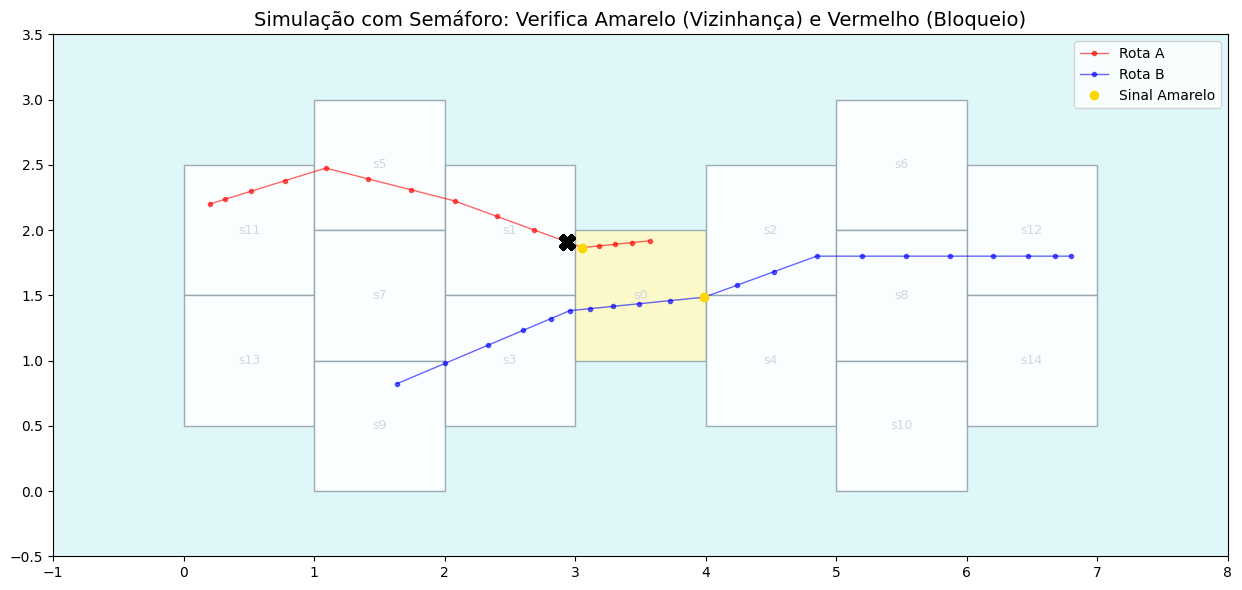

In [9]:
genTrace(init, trans, 20)

## Verificação da segurança do sistema com BMC



Para verificar a segurança do sistema, vamos utilizar BMC. Portanto, o objetivo será verificar se o invariante é verificado para todos os traços.
Vamos definir duas funções:

1. `prop_sufficient`: Verifica se os navios não estão no mesmo setor, isto é, $s_A \neq s_B$.
2. `prop_strong`: Verifica se ambos os navios não esperam, isto é, o semáfaro vermelho não é ligado, para além de verificar se ambos estão em setores distintos.

In [10]:
def prop_sufficient(s):
    return Not(Equals(s['A_s'], s['B_s']))

In [11]:
def prop_strong(s):
    return And(
        Not(Equals(s['A_s'], s['B_s'])),
        Not(Equals(s['A_sig'], Int(2))),
        Not(Equals(s['B_sig'], Int(2))),
    )

In [12]:
def bmc_always(declare, init, trans, inv, K):
    for n in range(1, K+1):
        with Solver(name="z3") as solver:
            X = [declare('X', i) for i in range(n + 1)]
            constraints = []

            constraints.append(init(X[0]))
            for i in range(n):
                constraints.append(trans(X[i], X[i+1]))

            constraints.append(Not(inv(X[-1])))
            
            solver.add_assertion(And(constraints))

            if solver.solve():
                print(f"\n[VIOLAÇÃO] Invariante falhou no passo k={n}!")
                print("-" * 50)
                
                model = solver.get_model()
                trace = []
                for i in range(n+1):
                    step_data = {}
                    for k, v in X[i].items():
                        if k.endswith('_s') or k.endswith('_sig'):
                            val = model.get_py_value(v)
                            step_data[k] = int(str(val))
                        else:
                            step_data[k] = extract_val(model, v)
                    trace.append(step_data)
                
                print_trace_log(trace)
                return False
                
    print(f"\n[SUCESSO] Nenhuma violação encontrada até o passo k={K}.")
    return True


In [13]:
bmc_always(declare, init, trans, prop_sufficient, 10)
bmc_always(declare, init, trans, prop_strong, 20)


[SUCESSO] Nenhuma violação encontrada até o passo k=10.

[VIOLAÇÃO] Invariante falhou no passo k=11!
--------------------------------------------------

| Passo | Tempo  || NAVIO A (Setor, X,Y, Sinal)                                       || NAVIO B (Setor, Global X,Y, Sinal)                                |
| 0     | 0.00   || S11 (0.20, 0.70) [VERDE] ANDANDO                                  || S12 (0.80, 0.30) [VERDE] ANDANDO                                  |
| 1     | 0.25   || S11 (0.32, 0.74) [VERDE] ANDANDO                                  || S12 (0.68, 0.30) [VERDE] ANDANDO                                  |
| 2     | 0.50   || S11 (0.51, 0.80) [VERDE] ANDANDO                                  || S12 (0.47, 0.30) [VERDE] ANDANDO                                  |
| 3     | 0.75   || S11 (0.77, 0.88) [VERDE] ANDANDO                                  || S12 (0.20, 0.30) [VERDE] ANDANDO                                  |
| 4     | 1.00   || S5  (0.09, 0.48) [VERDE] ANDANDO         

False